In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

# Optional (install if needed): pip install catboost
from catboost import CatBoostRegressor

from src.data.load import load_rideshare_data
from src.features.split import split_data

In [42]:
df = load_rideshare_data("../data/processed/rideshare_feature_engineering.csv")

In [43]:
df.head()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,log_distance,surge_x_distance,surge_intensity,is_surge,tier_enc,cab_type_enc,route_frequency,name_enc,destination_enc,source_enc
0,9,16,12,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,0.0000,0.0,0.68,8.66,9.17,10.000,43.68,34.19,37.95,27.39,32.70,1021.98,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07,0.364643,0.44,0.0,0,0,1,8874,7,7,5
1,2,27,11,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,0.1299,1.0,0.94,11.98,11.98,4.786,47.30,42.10,43.92,36.20,41.83,1003.97,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92,0.364643,0.44,0.0,0,2,1,8874,2,7,5
2,1,28,11,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,0.0000,0.0,0.75,7.33,7.33,10.000,47.55,33.10,44.12,29.11,31.10,992.28,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12,0.364643,0.44,0.0,0,1,1,8874,5,7,5
3,4,30,11,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,0.0000,0.0,0.73,5.28,5.28,10.000,45.03,28.90,38.53,26.20,26.64,1013.73,310,0.00,0,291.1,0.75,0.0000,34.67,45.03,30.30,38.53,0.364643,0.44,0.0,0,2,1,8874,4,7,5
4,3,29,11,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,0.0000,0.0,0.70,9.14,9.14,10.000,42.18,36.71,35.75,30.29,28.61,998.36,303,0.44,0,347.7,0.72,0.0001,33.10,42.18,29.11,35.75,0.364643,0.44,0.0,0,1,1,8874,6,7,5


In [44]:
df.columns

Index(['hour', 'day', 'month', 'price', 'distance', 'surge_multiplier',
       'latitude', 'longitude', 'temperature', 'apparentTemperature',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax', 'log_distance',
       'surge_x_distance', 'surge_intensity', 'is_surge', 'tier_enc',
       'cab_type_enc', 'route_frequency', 'name_enc', 'destination_enc',
       'source_enc'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 42 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   price                    637976 non-null  float64
 4   distance                 637976 non-null  float64
 5   surge_multiplier         637976 non-null  float64
 6   latitude                 637976 non-null  float64
 7   longitude                637976 non-null  float64
 8   temperature              637976 non-null  float64
 9   apparentTemperature      637976 non-null  float64
 10  precipIntensity          637976 non-null  float64
 11  precipProbability        637976 non-null  float64
 12  humidity                 637976 non-null  float64
 13  windSpeed                637976 non-null  float64
 14  wind

In [46]:
X_train, X_test, y_train, y_test = split_data(df)

In [ ]:
model_configs = [
    {
        "name": "LinearRegression",
        "model": LinearRegression(),
        "params": {}
    },
    {
        "name": "Ridge (Baseline)",
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
        }
    },
    {
        "name": "ExtraTrees",
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [200, 500, 800],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    {
        "name": "HistGradientBoosting",
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "max_iter": [300, 500, 800],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    },
    {
        "name": "CatBoost",
        "model": CatBoostRegressor(
            verbose=50,
            allow_writing_files=False,
            random_state=42
        ),
        "params": {
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "iterations": [300, 600, 1000]
        }
    }
]

In [48]:
# CV strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    return -scores.mean(), scores.std()


=== MODEL COMPARISON (CV RMSE) ===
Model           RMSE       Std       
LinearRegression 5.0831     0.0194    
Ridge (Baseline) 5.0831     0.0194    
ExtraTrees      1.9337     0.0153    
HistGradientBoosting 1.7024     0.0151    
CatBoost        1.6490     0.0123    


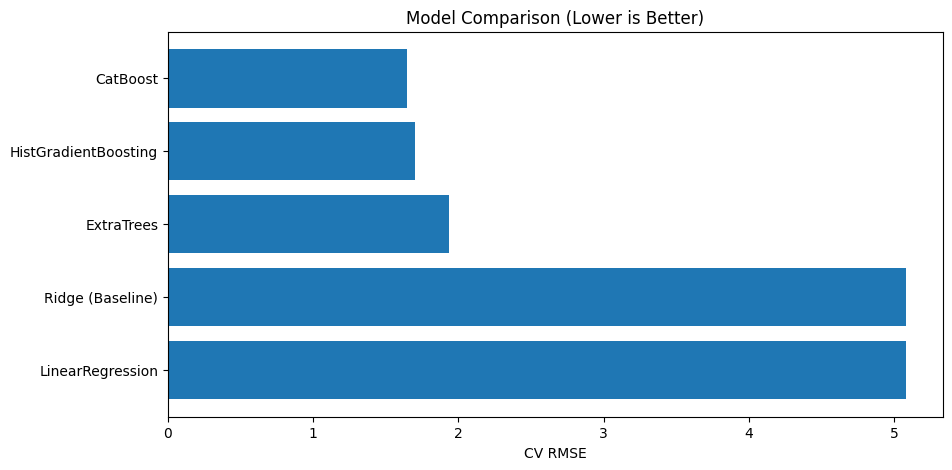

In [49]:
results = []

print("\n=== MODEL COMPARISON (CV RMSE) ===")
print(f"{'Model':<15} {'RMSE':<10} {'Std':<10}")

for cfg in model_configs:
    model = cfg["model"]

    rmse, std = rmse_cv(model, X_train, y_train)

    results.append({
        "Model": cfg["name"],
        "RMSE": rmse,
        "Std": std
    })

    print(f"{cfg['name']:<15} {rmse:<10.4f} {std:<10.4f}")


results_df = pd.DataFrame(results).sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(results_df["Model"], results_df["RMSE"])
plt.xlabel("CV RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
top_models = results_df["Model"].head(3).tolist()

tuned_results = []

print("\n=== HYPERPARAMETER TUNING (TOP MODELS) ===")
print(f"{'Model':<15} {'Best RMSE':<12} {'Best Params'}")

for cfg in model_configs:
    if cfg["name"] not in top_models:
        continue

    search = RandomizedSearchCV(
        estimator=cfg["model"],
        param_distributions=cfg["params"],
        n_iter=10,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    best_rmse = -search.best_score_

    tuned_results.append({
        "Model": cfg["name"],
        "RMSE": best_rmse,
        "BestEstimator": search.best_estimator_
    })

    print(f"{cfg['name']:<15} {best_rmse:<12.4f} {search.best_params_}")


tuned_df = pd.DataFrame(tuned_results).sort_values("RMSE")

plt.figure(figsize=(10, 5))
plt.barh(tuned_df["Model"], tuned_df["RMSE"])
plt.xlabel("Tuned CV RMSE")
plt.title("Tuned Model Comparison")
plt.gca().invert_yaxis()
plt.show()


=== HYPERPARAMETER TUNING (TOP MODELS) ===
Model           Best RMSE    Best Params


In [ ]:
best_model = tuned_results[0]["BestEstimator"]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("\n=== FINAL TEST EVALUATION ===")
print(f"RMSE: {final_rmse:.4f}")
print(f"R2  : {final_r2:.4f}")

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--r")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()